# MNIST Logistic Regression with TensorFlow

## Project Overview

This project implements linear and softmax-based classifiers with TensorFlow/Keras and compares how output activation, loss function, feature representation, and stacked linear layers affect MNIST performance.

A linear classifier is retained as a reference model so the effect of the softmax transformation can be evaluated directly.

### What This Project Demonstrates

- TensorFlow/Keras model construction
- Dense layers as \(XW+b\) transformations
- Linear vs. softmax output models
- Mean-squared-error vs. categorical-cross-entropy training
- Training and validation learning curves
- Quadratic pixel feature expansion
- Additional stacked linear layers
- Accuracy, MSE, MAE, and confusion-matrix comparison

## 1. Environment

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import *
from tensorflow.keras.activations import *
from keras.utils import plot_model
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, mean_absolute_error
import time


### Training-Curve Visualization

A reusable plotting function tracks training and validation accuracy and loss across epochs.

In [38]:
def plot_results(history):
  fig, ax = plt.subplots()
  ax.plot(history.history['accuracy'],label = 'train')
  ax.plot(history.history['val_accuracy'],label = 'test')
  ax.set_title('Accuracy')
  ax.legend(loc='lower right')
  fig, ax = plt.subplots()
  ax.plot(history.history['loss'],label = 'train')
  ax.plot(history.history['val_loss'],label = 'test')
  ax.set_title('Loss')
  ax.legend(loc='upper right')

## 2. MNIST Data Preparation

Images are normalized, flattened from \(28\times28\) into 784-element feature vectors, and labels are converted to 10-dimensional one-hot targets.

In [39]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1)
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)

# Convert y to one-hot
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

## 3. Reference Linear Output Model

The reference model contains a single Dense layer:

\[
y = XW + b
\]

It provides a direct comparison with the later softmax-based model.

In [40]:
def linear_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs))               # A Dense layer implements the function y = Wx + b
  return model

### Model Construction

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                     │ (None, 10)                  │           7,850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

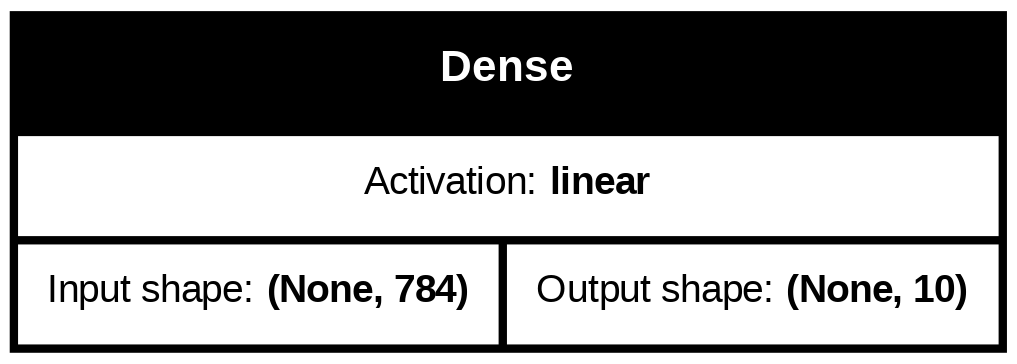

In [41]:
model = linear_regression(x_train.shape[1], y_train.shape[1])  # Create model with 784 inputs and 10 outputs
model.summary()                                                # Show model structure
model.compile(optimizer=tf.keras.optimizers.Adam(),  loss="mse", metrics=["accuracy"])               # Specify optimizer (optional) and loss function
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True) # Graphical depiction of model

### Training and Evaluation

Epoch 1/10
60/60 - 1s - 23ms/step - accuracy: 0.4564 - loss: 0.1179 - val_accuracy: 0.7043 - val_loss: 0.0691
Epoch 2/10
60/60 - 0s - 8ms/step - accuracy: 0.7520 - loss: 0.0607 - val_accuracy: 0.7974 - val_loss: 0.0538
Epoch 3/10
60/60 - 1s - 10ms/step - accuracy: 0.8032 - loss: 0.0513 - val_accuracy: 0.8261 - val_loss: 0.0484
Epoch 4/10
60/60 - 1s - 10ms/step - accuracy: 0.8216 - loss: 0.0472 - val_accuracy: 0.8347 - val_loss: 0.0456
Epoch 5/10
60/60 - 0s - 8ms/step - accuracy: 0.8296 - loss: 0.0450 - val_accuracy: 0.8444 - val_loss: 0.0439
Epoch 6/10
60/60 - 0s - 8ms/step - accuracy: 0.8367 - loss: 0.0435 - val_accuracy: 0.8468 - val_loss: 0.0427
Epoch 7/10
60/60 - 0s - 8ms/step - accuracy: 0.8395 - loss: 0.0425 - val_accuracy: 0.8466 - val_loss: 0.0419
Epoch 8/10
60/60 - 0s - 8ms/step - accuracy: 0.8428 - loss: 0.0417 - val_accuracy: 0.8516 - val_loss: 0.0412
Epoch 9/10
60/60 - 1s - 10ms/step - accuracy: 0.8454 - loss: 0.0411 - val_accuracy: 0.8529 - val_loss: 0.0409
Epoch 10/10
60/

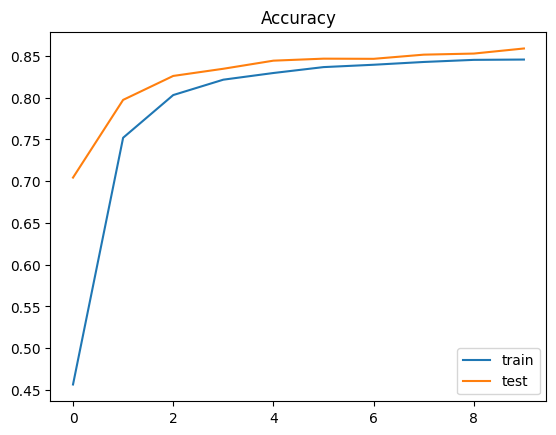

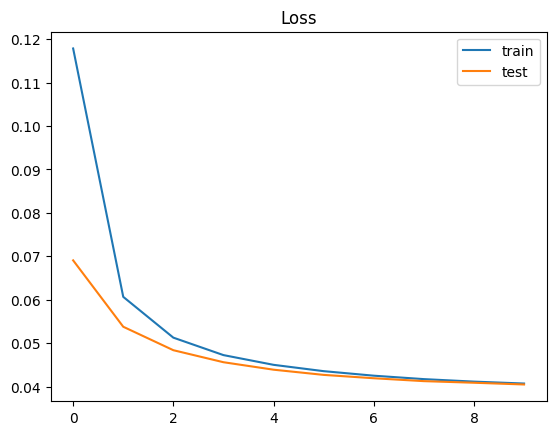

In [42]:
start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 10,
    batch_size = 1000,
    verbose = 2, # Print loss and accuracy after each epoch; set to 0 for final output only
    validation_data=(x_test, y_test), # Track validation loss and accuracy during training
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

## 4. Softmax Logistic Model

The same linear class-score layer is followed by a Softmax activation, converting the 10 output scores into a normalized class-probability distribution.

In [43]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs))
  model.add(Softmax())
  return model

### Softmax Model Trained with Mean Squared Error

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                     │ (None, 10)                  │           7,850 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ softmax_4 (Softmax)                  │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

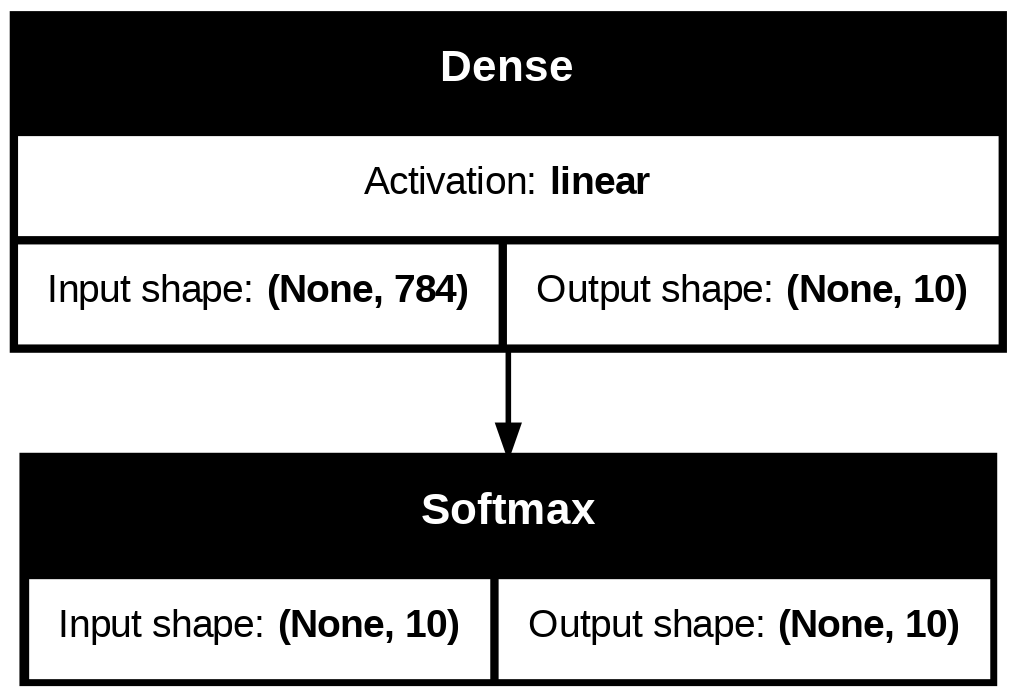

In [44]:
model = logistic_regression(x_train.shape[1], y_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),  loss="mse", metrics=["accuracy"])                # Specify optimizer (optional) and loss function
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

Epoch 1/40
60/60 - 2s - 38ms/step - accuracy: 0.6388 - loss: 0.0592 - val_accuracy: 0.8262 - val_loss: 0.0348
Epoch 2/40
60/60 - 2s - 38ms/step - accuracy: 0.8485 - loss: 0.0291 - val_accuracy: 0.8758 - val_loss: 0.0234
Epoch 3/40
60/60 - 1s - 20ms/step - accuracy: 0.8762 - loss: 0.0223 - val_accuracy: 0.8905 - val_loss: 0.0196
Epoch 4/40
60/60 - 1s - 13ms/step - accuracy: 0.8896 - loss: 0.0194 - val_accuracy: 0.8993 - val_loss: 0.0175
Epoch 5/40
60/60 - 1s - 9ms/step - accuracy: 0.8977 - loss: 0.0177 - val_accuracy: 0.9057 - val_loss: 0.0162
Epoch 6/40
60/60 - 0s - 8ms/step - accuracy: 0.9029 - loss: 0.0165 - val_accuracy: 0.9090 - val_loss: 0.0153
Epoch 7/40
60/60 - 1s - 10ms/step - accuracy: 0.9064 - loss: 0.0157 - val_accuracy: 0.9121 - val_loss: 0.0147
Epoch 8/40
60/60 - 1s - 11ms/step - accuracy: 0.9101 - loss: 0.0150 - val_accuracy: 0.9128 - val_loss: 0.0142
Epoch 9/40
60/60 - 0s - 8ms/step - accuracy: 0.9120 - loss: 0.0145 - val_accuracy: 0.9162 - val_loss: 0.0138
Epoch 10/40
6

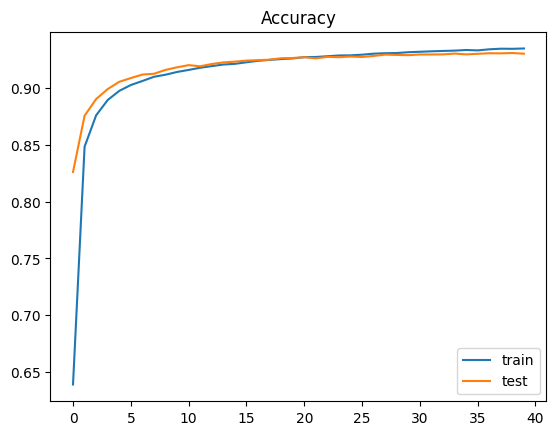

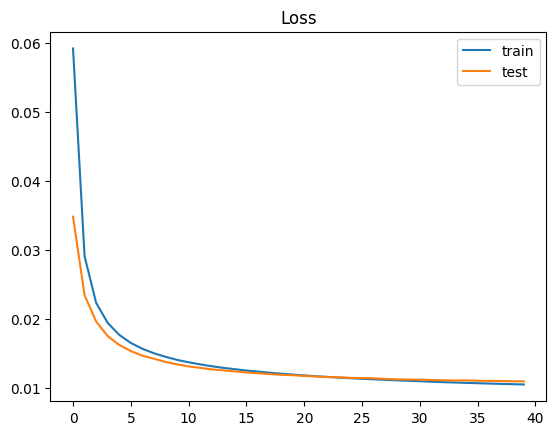

In [45]:
start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2, # Print loss and accuracy after each epoch; set to 0 for final output only
    validation_data=(x_test, y_test), # Track validation loss and accuracy during training
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

## 5. Loss-Function Comparison

The softmax architecture is kept unchanged while the loss is changed from mean squared error to categorical cross-entropy. This isolates the effect of the training objective.

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 10)                  │           7,850 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ softmax_5 (Softmax)                  │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

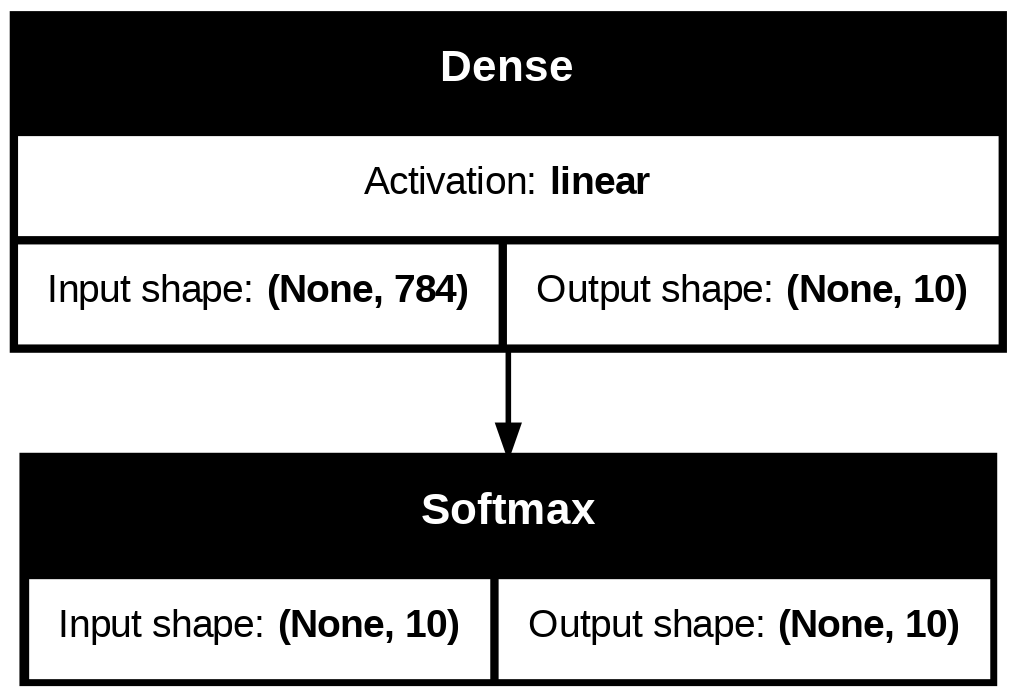

In [46]:
model = logistic_regression(x_train.shape[1], y_train.shape[1])
model.summary()
opt = tf.keras.optimizers.Adam()
model.compile(optimizer=opt, loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

Epoch 1/40
60/60 - 1s - 22ms/step - accuracy: 0.6156 - loss: 1.4688 - val_accuracy: 0.8166 - val_loss: 0.8942
Epoch 2/40
60/60 - 1s - 8ms/step - accuracy: 0.8368 - loss: 0.7509 - val_accuracy: 0.8647 - val_loss: 0.6059
Epoch 3/40
60/60 - 1s - 11ms/step - accuracy: 0.8661 - loss: 0.5699 - val_accuracy: 0.8844 - val_loss: 0.4965
Epoch 4/40
60/60 - 1s - 13ms/step - accuracy: 0.8801 - loss: 0.4874 - val_accuracy: 0.8954 - val_loss: 0.4394
Epoch 5/40
60/60 - 1s - 21ms/step - accuracy: 0.8881 - loss: 0.4395 - val_accuracy: 0.9003 - val_loss: 0.4024
Epoch 6/40
60/60 - 1s - 16ms/step - accuracy: 0.8946 - loss: 0.4076 - val_accuracy: 0.9039 - val_loss: 0.3777
Epoch 7/40
60/60 - 1s - 10ms/step - accuracy: 0.8992 - loss: 0.3846 - val_accuracy: 0.9066 - val_loss: 0.3596
Epoch 8/40
60/60 - 0s - 8ms/step - accuracy: 0.9032 - loss: 0.3673 - val_accuracy: 0.9098 - val_loss: 0.3457
Epoch 9/40
60/60 - 0s - 8ms/step - accuracy: 0.9059 - loss: 0.3538 - val_accuracy: 0.9118 - val_loss: 0.3344
Epoch 10/40
6

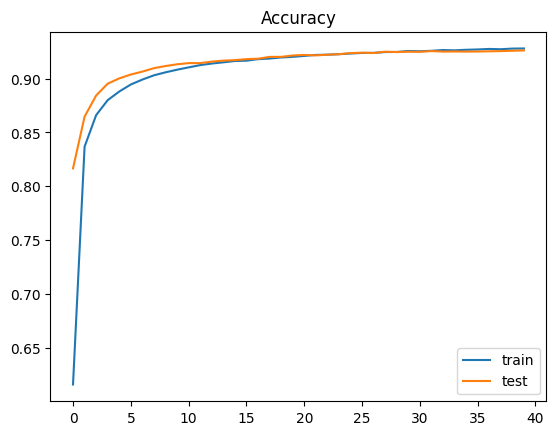

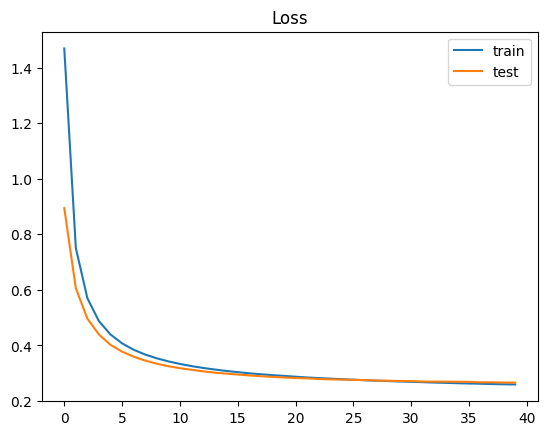

In [47]:
start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2, # Print loss and accuracy after each epoch; set to 0 for final output only
    validation_data=(x_test, y_test), # Track validation loss and accuracy during training
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

## 6. Quadratic Pixel Feature Expansion

Each normalized pixel feature is supplemented with its squared value, increasing the input dimension from 784 to 1,568. Both the linear reference model and the softmax model are reevaluated using the expanded representation.

In [48]:
x_train = np.hstack((x_train,x_train**2))
x_test = np.hstack((x_test,x_test**2))

### Expanded Feature Dimension

After concatenating each pixel with its squared value, the input dimension increases from 784 to 1,568 features.

In [ ]:
x_train.shape

### Linear Reference Model with Quadratic Features

In [49]:
def linear_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs))
  return model

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                     │ (None, 10)                  │          15,690 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,690 (61.29 KB)

 Trainable params: 15,690 (61.29 KB)

 Non-trainable params: 0 (0.00 B)

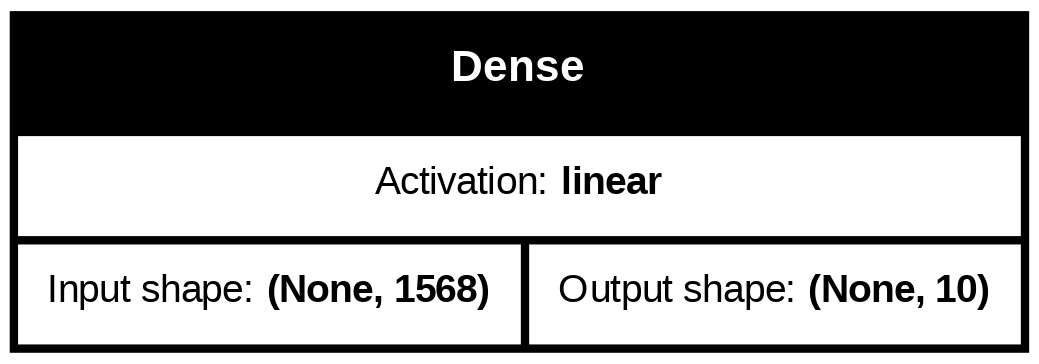

In [50]:
model = linear_regression(x_train.shape[1], y_train.shape[1])                                        # Create model with 784 inputs and 10 outputs
model.summary()                                                                                      # Show model structure
model.compile(optimizer=tf.keras.optimizers.Adam(),  loss="mse", metrics=["accuracy"])               # Specify optimizer (optional) and loss function
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)             # Graphical depiction of model

In [51]:
start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 10,
    batch_size = 1000,
    verbose = 2, # Print loss and accuracy after each epoch; set to 0 for final output only
    validation_data=(x_test, y_test), # Track validation loss and accuracy during training
)
end_train = time.time()

Epoch 1/10
60/60 - 2s - 28ms/step - accuracy: 0.5991 - loss: 0.0928 - val_accuracy: 0.7837 - val_loss: 0.0565
Epoch 2/10
60/60 - 1s - 19ms/step - accuracy: 0.7950 - loss: 0.0521 - val_accuracy: 0.8236 - val_loss: 0.0478
Epoch 3/10
60/60 - 1s - 23ms/step - accuracy: 0.8212 - loss: 0.0467 - val_accuracy: 0.8345 - val_loss: 0.0447
Epoch 4/10
60/60 - 1s - 19ms/step - accuracy: 0.8310 - loss: 0.0441 - val_accuracy: 0.8440 - val_loss: 0.0429
Epoch 5/10
60/60 - 1s - 20ms/step - accuracy: 0.8371 - loss: 0.0426 - val_accuracy: 0.8492 - val_loss: 0.0417
Epoch 6/10
60/60 - 1s - 21ms/step - accuracy: 0.8418 - loss: 0.0415 - val_accuracy: 0.8526 - val_loss: 0.0407
Epoch 7/10
60/60 - 1s - 20ms/step - accuracy: 0.8450 - loss: 0.0408 - val_accuracy: 0.8518 - val_loss: 0.0403
Epoch 8/10
60/60 - 1s - 11ms/step - accuracy: 0.8473 - loss: 0.0402 - val_accuracy: 0.8556 - val_loss: 0.0399
Epoch 9/10
60/60 - 2s - 26ms/step - accuracy: 0.8507 - loss: 0.0396 - val_accuracy: 0.8574 - val_loss: 0.0393
Epoch 10/1

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Elapsed time training= 13.4055 secs
Mean squared error = 0.039
Mean absolute error =  0.134
Accuracy = 0.8619
Confusion matrix
[[ 943    0    3    2    0    9   13    2    6    2]
 [   0 1104    4    1    4    0    5    1   16    0]
 [  17   45  847   16   19    0   34   16   34    4]
 [   7   16   25  887    3   19    7   21   15   10]
 [   1   21   10    0  887    3    8    2    9   41]
 [  20   13    3   77   20  663   21   13   41   21]
 [  26    8   19    0   22   20  856    0    7    0]
 [   4   38   16    7   23    2    1  889    0   48]
 [  16   48   14   39   24   51   14   13  727   28]
 [  17   13    2   20   71    0    1   65    4  816]]


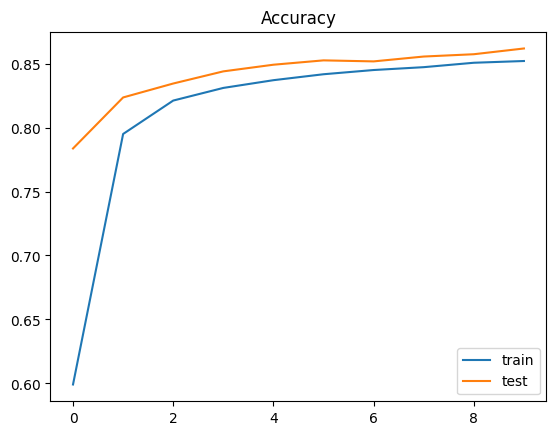

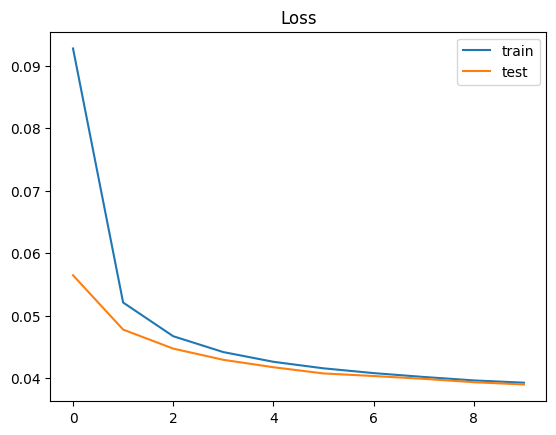

In [52]:
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))


### Softmax Logistic Model with Quadratic Features

In [53]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs))
  model.add(Softmax())
  return model

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                     │ (None, 10)                  │          15,690 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ softmax_6 (Softmax)                  │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,690 (61.29 KB)

 Trainable params: 15,690 (61.29 KB)

 Non-trainable params: 0 (0.00 B)

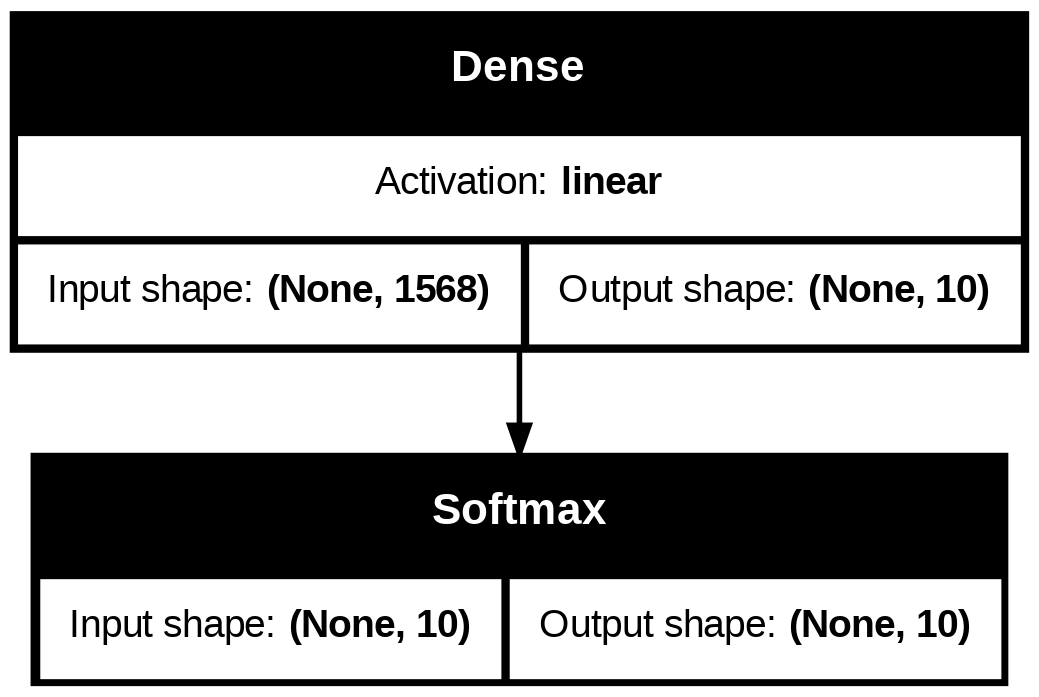

In [54]:
model = logistic_regression(x_train.shape[1], y_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),  loss="CategoricalCrossentropy", metrics=["accuracy"])                # Specify optimizer (optional) and loss function
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

In [55]:
start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2, # Print loss and accuracy after each epoch; set to 0 for final output only
    validation_data=(x_test, y_test), # Track validation loss and accuracy during training
)
end_train = time.time()

Epoch 1/40
60/60 - 2s - 27ms/step - accuracy: 0.6966 - loss: 1.1776 - val_accuracy: 0.8545 - val_loss: 0.6224
Epoch 2/40
60/60 - 1s - 18ms/step - accuracy: 0.8665 - loss: 0.5461 - val_accuracy: 0.8884 - val_loss: 0.4538
Epoch 3/40
60/60 - 1s - 20ms/step - accuracy: 0.8868 - loss: 0.4403 - val_accuracy: 0.9007 - val_loss: 0.3920
Epoch 4/40
60/60 - 1s - 21ms/step - accuracy: 0.8970 - loss: 0.3917 - val_accuracy: 0.9077 - val_loss: 0.3585
Epoch 5/40
60/60 - 1s - 20ms/step - accuracy: 0.9036 - loss: 0.3629 - val_accuracy: 0.9109 - val_loss: 0.3380
Epoch 6/40
60/60 - 1s - 24ms/step - accuracy: 0.9085 - loss: 0.3434 - val_accuracy: 0.9137 - val_loss: 0.3240
Epoch 7/40
60/60 - 1s - 24ms/step - accuracy: 0.9115 - loss: 0.3295 - val_accuracy: 0.9154 - val_loss: 0.3132
Epoch 8/40
60/60 - 1s - 20ms/step - accuracy: 0.9139 - loss: 0.3184 - val_accuracy: 0.9174 - val_loss: 0.3055
Epoch 9/40
60/60 - 1s - 16ms/step - accuracy: 0.9165 - loss: 0.3100 - val_accuracy: 0.9178 - val_loss: 0.2995
Epoch 10/4

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Elapsed time training= 47.1538 secs
Mean squared error = 0.011
Mean absolute error =  0.024
Accuracy = 0.9287
Confusion matrix
[[ 963    0    1    1    0    4    6    4    1    0]
 [   0 1118    3    3    0    1    3    2    5    0]
 [   6   11  919   20    7    4   10   11   41    3]
 [   2    0   16  935    0   19    2   11   20    5]
 [   1    1    3    2  918    0   11    5   10   31]
 [   8    2    2   42    9  772   14    8   30    5]
 [   9    3    5    2    7   13  915    2    2    0]
 [   1    6   23    5    3    1    0  959    3   27]
 [   7    9    6   26    8   24    9   12  868    5]
 [  11    7    1   12   24    5    0   24    5  920]]


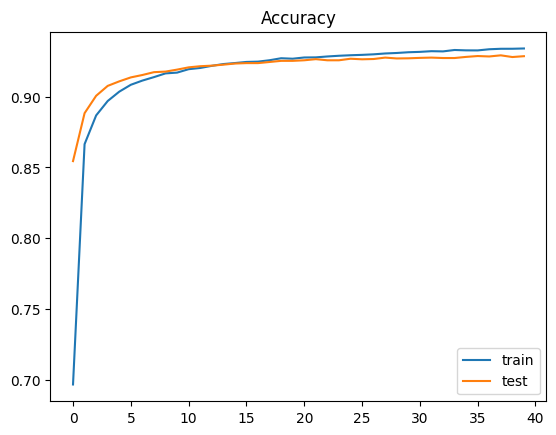

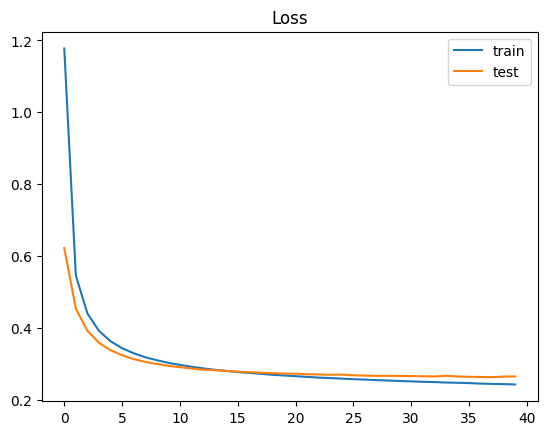

In [56]:
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

## 7. Stacked Linear Layers

The next comparison adds another Dense layer without a nonlinear activation. Because both Dense layers remain linear transformations, the experiment evaluates a different parameterization of the linear mapping rather than introducing a nonlinear hidden representation.

### Stacked Linear Output Model

In [57]:
def linear_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs)) # another layer
  model.add(Dense(n_outputs))
  return model

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                     │ (None, 10)                  │          15,690 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 10)                  │             110 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,800 (61.72 KB)

 Trainable params: 15,800 (61.72 KB)

 Non-trainable params: 0 (0.00 B)

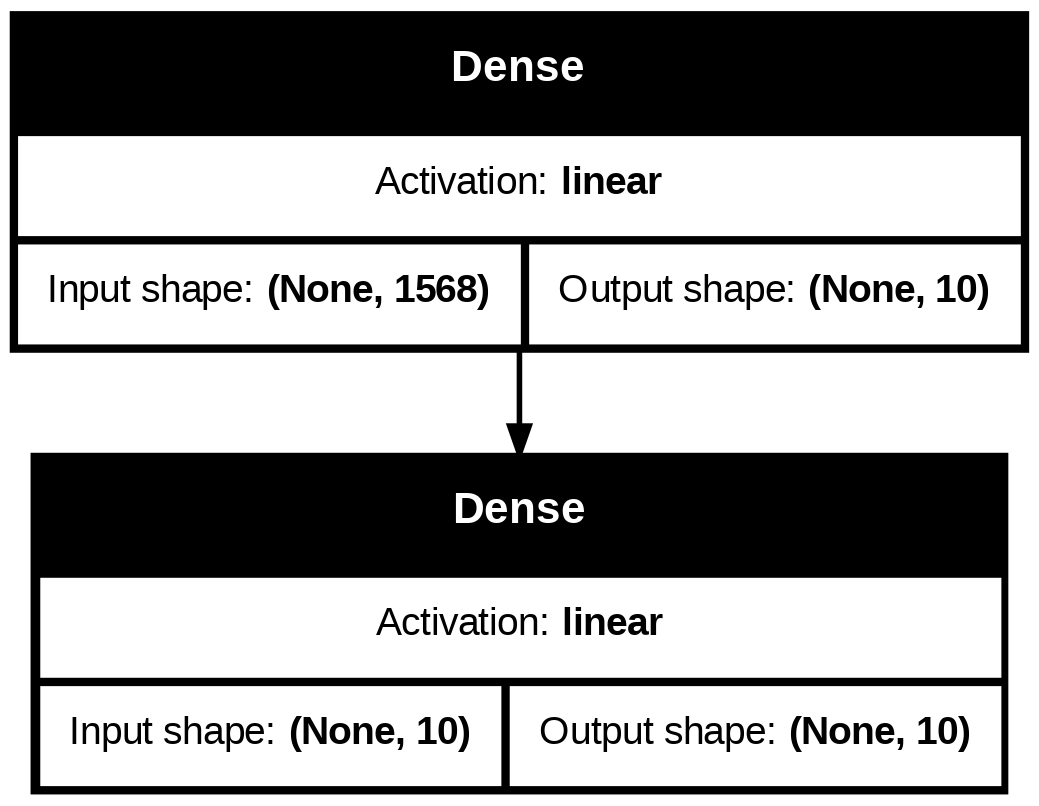

In [58]:
model = linear_regression(x_train.shape[1], y_train.shape[1])                                        # Create model with 784 inputs and 10 outputs
model.summary()                                                                                      # Show model structure
model.compile(optimizer=tf.keras.optimizers.Adam(),  loss="mse", metrics=["accuracy"])               # Specify optimizer (optional) and loss function
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)             # Graphical depiction of model

In [59]:
start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 10,
    batch_size = 1000,
    verbose = 2, # Print loss and accuracy after each epoch; set to 0 for final output only
    validation_data=(x_test, y_test), # Track validation loss and accuracy during training
)
end_train = time.time()

Epoch 1/10
60/60 - 2s - 30ms/step - accuracy: 0.5372 - loss: 0.0958 - val_accuracy: 0.7346 - val_loss: 0.0606
Epoch 2/10
60/60 - 1s - 12ms/step - accuracy: 0.7671 - loss: 0.0549 - val_accuracy: 0.8113 - val_loss: 0.0494
Epoch 3/10
60/60 - 1s - 21ms/step - accuracy: 0.8152 - loss: 0.0475 - val_accuracy: 0.8382 - val_loss: 0.0446
Epoch 4/10
60/60 - 1s - 13ms/step - accuracy: 0.8323 - loss: 0.0441 - val_accuracy: 0.8481 - val_loss: 0.0425
Epoch 5/10
60/60 - 1s - 14ms/step - accuracy: 0.8404 - loss: 0.0424 - val_accuracy: 0.8515 - val_loss: 0.0413
Epoch 6/10
60/60 - 1s - 21ms/step - accuracy: 0.8446 - loss: 0.0414 - val_accuracy: 0.8557 - val_loss: 0.0403
Epoch 7/10
60/60 - 2s - 27ms/step - accuracy: 0.8482 - loss: 0.0405 - val_accuracy: 0.8619 - val_loss: 0.0399
Epoch 8/10
60/60 - 1s - 19ms/step - accuracy: 0.8512 - loss: 0.0399 - val_accuracy: 0.8627 - val_loss: 0.0394
Epoch 9/10
60/60 - 1s - 17ms/step - accuracy: 0.8530 - loss: 0.0395 - val_accuracy: 0.8631 - val_loss: 0.0389
Epoch 10/1

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Elapsed time training= 12.4094 secs
Mean squared error = 0.039
Mean absolute error =  0.133
Accuracy = 0.8637
Confusion matrix
[[ 942    0    1    3    2    9   12    2    8    1]
 [   0 1112    3    0    5    0    5    2    8    0]
 [  19   59  817   23   17    1   38   19   33    6]
 [   6   23   23  885    4   15    8   19   16   11]
 [   1   26    5    1  876    2    9    2    7   53]
 [  16   15    5   80   22  660   23   15   37   19]
 [  24    8    6    1   17   19  879    0    4    0]
 [   5   45   15    8   23    1    2  870    2   57]
 [  16   49    8   34   26   36   16    9  757   23]
 [  17   13    2   16   55    2    1   59    5  839]]


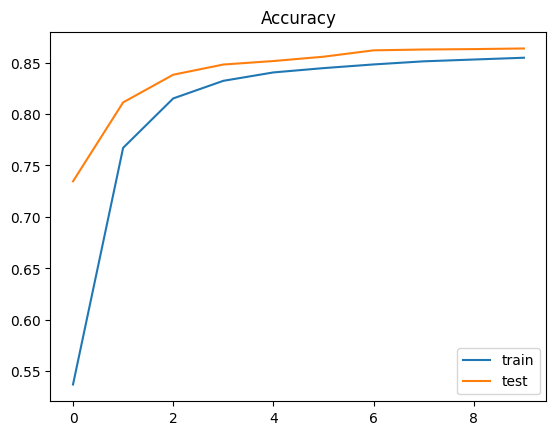

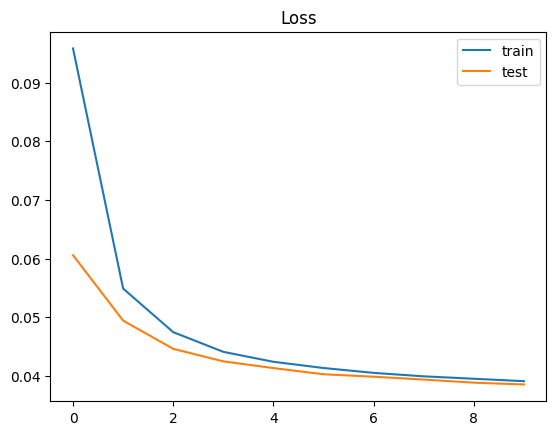

In [60]:
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

### Stacked Linear Layers with Softmax Output

In [61]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs)) # another layer
  model.add(Dense(n_outputs))
  model.add(Softmax())
  return model

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                     │ (None, 10)                  │          15,690 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ softmax_7 (Softmax)                  │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,800 (61.72 KB)

 Trainable params: 15,800 (61.72 KB)

 Non-trainable params: 0 (0.00 B)

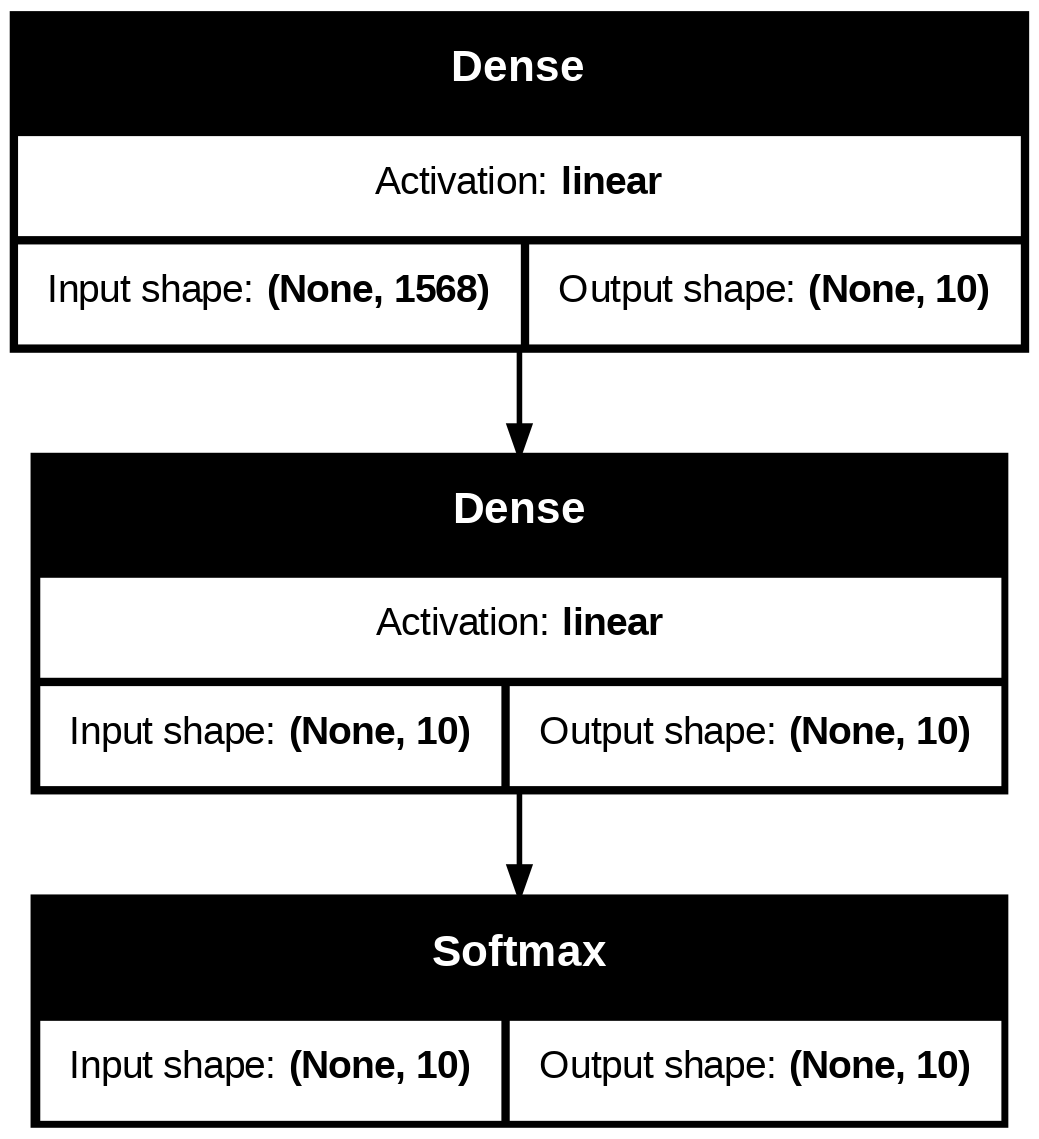

In [62]:
model = logistic_regression(x_train.shape[1], y_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),  loss="CategoricalCrossentropy", metrics=["accuracy"])                # Specify optimizer (optional) and loss function
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

In [63]:
start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2, # Print loss and accuracy after each epoch; set to 0 for final output only
    validation_data=(x_test, y_test), # Track validation loss and accuracy during training
)
end_train = time.time()

Epoch 1/40
60/60 - 3s - 46ms/step - accuracy: 0.6765 - loss: 1.1622 - val_accuracy: 0.8441 - val_loss: 0.6354
Epoch 2/40
60/60 - 1s - 17ms/step - accuracy: 0.8583 - loss: 0.5428 - val_accuracy: 0.8831 - val_loss: 0.4454
Epoch 3/40
60/60 - 1s - 20ms/step - accuracy: 0.8856 - loss: 0.4241 - val_accuracy: 0.8980 - val_loss: 0.3766
Epoch 4/40
60/60 - 1s - 16ms/step - accuracy: 0.8974 - loss: 0.3708 - val_accuracy: 0.9066 - val_loss: 0.3425
Epoch 5/40
60/60 - 1s - 15ms/step - accuracy: 0.9058 - loss: 0.3400 - val_accuracy: 0.9128 - val_loss: 0.3180
Epoch 6/40
60/60 - 1s - 24ms/step - accuracy: 0.9119 - loss: 0.3195 - val_accuracy: 0.9159 - val_loss: 0.3040
Epoch 7/40
60/60 - 1s - 15ms/step - accuracy: 0.9152 - loss: 0.3057 - val_accuracy: 0.9196 - val_loss: 0.2925
Epoch 8/40
60/60 - 1s - 17ms/step - accuracy: 0.9184 - loss: 0.2951 - val_accuracy: 0.9215 - val_loss: 0.2861
Epoch 9/40
60/60 - 1s - 22ms/step - accuracy: 0.9205 - loss: 0.2873 - val_accuracy: 0.9227 - val_loss: 0.2837
Epoch 10/4

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Elapsed time training= 46.2772 secs
Mean squared error = 0.011
Mean absolute error =  0.023
Accuracy = 0.9305
Confusion matrix
[[ 964    0    1    2    0    6    3    3    1    0]
 [   0 1117    4    2    1    1    3    2    5    0]
 [   5    8  944   13    7    3   11    9   29    3]
 [   3    0   25  930    0   18    2    9   19    4]
 [   1    1    8    2  915    0   11    5   10   29]
 [   8    2    3   41    8  779   10    7   31    3]
 [  10    3    7    1    7   19  907    2    2    0]
 [   1    6   22    7    4    2    0  955    3   28]
 [   7    9    7   21    6   20   10    8  880    6]
 [   7    9    2   11   24    8    0   22   12  914]]


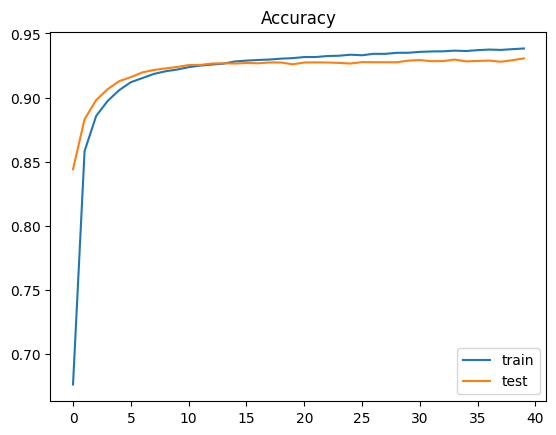

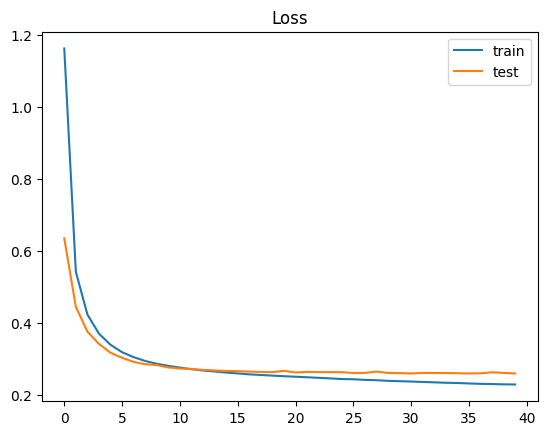

In [64]:
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

## 8. Comparative Results

| TensorFlow Configuration | Test Accuracy |
|---|---:|
| Single Dense linear output, MSE | 0.8590 |
| Single Dense + Softmax, MSE | 0.9305 |
| Single Dense + Softmax, categorical cross-entropy | 0.9263 |
| Linear output with quadratic features | 0.8619 |
| Softmax + categorical cross-entropy with quadratic features | 0.9287 |
| Two stacked linear Dense layers, MSE | 0.8637 |
| Two stacked linear Dense layers + Softmax | 0.9305 |

These saved experiments show a large improvement when the output is converted from unconstrained linear scores to a softmax probability distribution. In this run, quadratic features and the additional linear layer do not exceed the best saved softmax result of **0.9305**.

## 9. Key Findings

- A Dense layer implements the same core \(XW+b\) transformation used by classical linear models.
- Softmax substantially improves multiclass behavior relative to an unconstrained linear output in the saved MNIST experiments.
- Changing the loss function changes optimization behavior even when the model architecture is unchanged.
- Quadratic pixel features provide only a small change in the TensorFlow results shown here.
- Stacking linear Dense layers without an activation does not introduce a nonlinear representation.
- Training and validation curves provide useful evidence about convergence and generalization across configurations.